<a href="https://colab.research.google.com/github/Dnntello/Prodigy_ML_04/blob/main/hand_gesture_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Important steps:
* Collect gesture images
* Preprocess images
* Create PyTorch dataset
* Build CNN
* Train model
* Evaluate accuracy
* Predict gestures

Each image has:
* a subject folder (00, 01, …)
* a gesture folder (01_palm, 02_fist, etc.)

But I only care about:
* the gesture name

In [ ]:
# import zipfile

# zip_path = "/content/drive/MyDrive/archive (2).zip"
# extract_path = "drive/MyDrive/"

# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#   zip_ref.extractall(extract_path)

Let's readjust our dataset

In [ ]:
# import shutil
# from pathlib import Path

# old_dataset = Path("/content/drive/MyDrive//leapGestRecog")
# new_dataset = Path("drive/MyDrive/hand_gestures")

# new_dataset.mkdir(parents=True,
#                   exist_ok=True)

# for subject_folder in old_dataset.iterdir():

#     if not subject_folder.is_dir():
#         continue

#     print(f"\nSubject: {subject_folder.name}")

#     for gesture_folder in subject_folder.iterdir():

#         try:

#             if not gesture_folder.is_dir():
#                 continue

#             print(f"Gesture: {gesture_folder.name}")

#             gesture_name = gesture_folder.name

#             target_folder = new_dataset / gesture_name
#             target_folder.mkdir(exist_ok=True)

#             copied = 0

#             for img_file in gesture_folder.iterdir():

#                 if (img_file.is_file() and img_file.suffix.lower()
#                     in [".png", ".jpg", ".jpeg"]):

#                     new_name = (f"{subject_folder.name}_{img_file.name}")

#                     shutil.copy(
#                         img_file,
#                         target_folder / new_name)

#                     copied += 1

#             print(f"Copied {copied} images")

#         except Exception as e:

#             print(f"ERROR in {gesture_folder.name}: {e}")

In [ ]:
#to copy dataset to content

!cp -r drive/MyDrive/hand_gestures /content/

## Import tools and define transforms

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from torch import nn

dataset_path = "/content/hand_gestures"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],
                         std=[0.5])
])

In [ ]:
#device agnostics bruv
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# Lets remove corrupted images
from PIL import Image
import os

bad_files=[]
for root, dirs, files in os.walk(dataset_path):
  for file in files:
    path = os.path.join(root, file)
    try:
      img = Image.open(path)
      img.verify()
    except (IOError, SyntaxError) as e:
      bad_files.append(path)

print(f"Found {len(bad_files)} corrupted images")
for file in bad_files:
  print(f"Removing {file}")
  os.remove(file)

Found 0 corrupted images


In [ ]:
def load_dataset(dataset_path, transform):

  dataset = datasets.ImageFolder(
      root = dataset_path,
      transform = transform
  )

  return dataset

Lets seperate our data to train and test

In [ ]:
def split_dataset(dataset, test_size=0.2):
  indices = list(range(len(dataset)))
  labels = dataset.targets

  train_indices, test_indices = train_test_split(
      indices,
      test_size = 0.2,
      stratify = labels,
      random_state = 42
  )

  train_dataset = Subset(dataset, train_indices)
  test_dataset = Subset(dataset, test_indices)

  return train_dataset, test_dataset

In [ ]:
def create_dataloaders(train_dataset, test_dataset, batch_size=64):
  '''
  A function to load our data into batches
  and returns dataloaders for train and test
  '''
  train_loader = DataLoader(
      train_dataset,
      batch_size = batch_size,
      shuffle = True,
      num_workers = 2,
      pin_memory = True,
      persistent_workers=True
  )
  test_loader = DataLoader(
      test_dataset,
      batch_size = batch_size,
      shuffle = False,
      num_workers=2,
      pin_memory=True,
      persistent_workers=True
  )

  return train_loader, test_loader

In [ ]:
#load dataset
dataset = load_dataset(dataset_path, transform)

# train and test
train_dataset, test_dataset = split_dataset(dataset)

#batching
train_loader, test_loader = create_dataloaders(train_dataset, test_dataset)



## create our CNN module

In [ ]:
from torch import nn
class GestureCNN(nn.Module):
  def __init__(self, num_classes=10):
    super().__init__()

    self.features = nn.Sequential(
        #block 1
        nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        ),

        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        #block 2
        nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        ),

        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        #block 3
        nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.AdaptiveAvgPool2d((1, 1))

    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)

    return x

In [ ]:
#initialize the model
model = GestureCNN(num_classes=10)

## Loss function and optimizer

* I am going to use cross entropy because this a standard for multiclass classification

* I will use softmax as my optimizer

In [ ]:
#loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr = 0.001)

In [ ]:
device

'cuda'

## Training and test loop

In [ ]:
from numpy.matrixlib import test

def train_loop(model, loss_fn = loss_fn, optimizer = optimizer,
               train_loader = train_loader, test_loader = test_loader,
               device = device):
  '''
  Returns:
  epoch_count, train_losses, test_losses,
  train_accuracies, test_accuracies and model
  '''
  epochs = 10
  epoch_count = []
  train_losses = []
  test_losses = []
  train_accuracies = []
  test_accuracies = []


  for epoch in range(epochs):
    ## TRAINING
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    train_loss=0

    for images, labels in train_loader:
      images = images.to(device)
      labels = labels.to(device)

      #clear previous gradients
      optimizer.zero_grad()

      #forward pass
      outputs = model(images)

      #compute the loss
      loss = loss_fn(outputs, labels)

      #backpropagation
      loss.backward()

      #step
      optimizer.step()

      running_loss += loss.item()  #accumulated batch loss
      _, predicted = torch.max(outputs, 1) #predictions
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    epoch_count.append(epoch + 1)
    train_loss = running_loss / len(train_loader) #average loss
    train_losses.append(train_loss)
    train_accuracies.append(100 * correct / total)

    ##testing
    model.eval()

    test_running_loss = 0
    test_correct = 0
    test_total = 0
    test_loss = 0

    with torch.inference_mode():
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, labels)
        test_running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)

        test_correct += (predicted ==labels).sum().item()

      test_loss = test_running_loss / len(test_loader)
      test_losses.append(test_running_loss / len(test_loader))
      test_accuracies.append(100 * test_correct / test_total)


      print(
          f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Accuracy: {train_accuracies[epoch]}%")
      print(
          f"Test Loss: {test_loss:.4f} | "
          f"Test Accuracy: {test_accuracies[epoch]}%"
      )


  return epoch_count, train_losses, test_losses, train_accuracies, test_accuracies, model



In [ ]:
%time
epoch_count, train_losses, test_losses, train_accuracies, test_accuracies, model = train_loop(model)

CPU times: user 15 µs, sys: 1 µs, total: 16 µs
Wall time: 20.5 µs
Epoch [1/10] | Train Loss: 1.9886 | Train Accuracy: 24.93130152385711%
Test Loss: 1.3856 | Test Accuracy: 50.01249063202598%
Epoch [2/10] | Train Loss: 1.0291 | Train Accuracy: 63.52110916812391%
Test Loss: 0.6632 | Test Accuracy: 73.8446165375968%
Epoch [3/10] | Train Loss: 0.5789 | Train Accuracy: 79.47789158131401%
Test Loss: 0.4528 | Test Accuracy: 83.06270297277042%
Epoch [4/10] | Train Loss: 0.4085 | Train Accuracy: 86.00424681488883%
Test Loss: 0.2184 | Test Accuracy: 94.37921558830877%
Epoch [5/10] | Train Loss: 0.2854 | Train Accuracy: 90.51961029228079%
Test Loss: 0.1623 | Test Accuracy: 95.77816637521859%
Epoch [6/10] | Train Loss: 0.2062 | Train Accuracy: 93.09892580564576%
Test Loss: 0.2525 | Test Accuracy: 91.03172620534599%
Epoch [7/10] | Train Loss: 0.1625 | Train Accuracy: 94.69148138895828%
Test Loss: 0.0935 | Test Accuracy: 97.42692980264802%
Epoch [8/10] | Train Loss: 0.1352 | Train Accuracy: 95.62827

In [ ]:
#save model
from pathlib import Path

MODEL_PATH = Path("/content/drive/MyDrive/models")

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True)
MODEL_NAME = "gesture_cnn_v1.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(
    model.state_dict(),
    MODEL_SAVE_PATH
)

print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to /content/drive/MyDrive/models/gesture_cnn_v1.pth


In [ ]:
MODEL_SAVE_PATH

PosixPath('/content/drive/MyDrive/models/gesture_cnn_v1.pth')

In [ ]:
#Load model
import torch

loaded_model_1 = GestureCNN()
loaded_model_1.load_state_dict(torch.load('/content/drive/MyDrive/models/gesture_cnn_v1.pth',
                                          map_location = torch.device('cpu')))


<All keys matched successfully>

## Lets evaluate

In [ ]:
loaded_model_1.eval()
with torch.inference_mode():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = loaded_model_1(images)

    predicted = torch.argmax(outputs, 1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "epoch": epoch_count,
    "train_loss": train_losses,
    "test_loss": test_losses,
    "train_accuracy": train_accuracies,
    "test_accuracy": test_accuracies
})

results.to_csv(
    "/content/drive/MyDrive/models/training_results.csv",
    index=False
)

In [ ]:
import pandas as pd
results = pd.read_csv("/content/drive/MyDrive/models/training_results_1.csv")

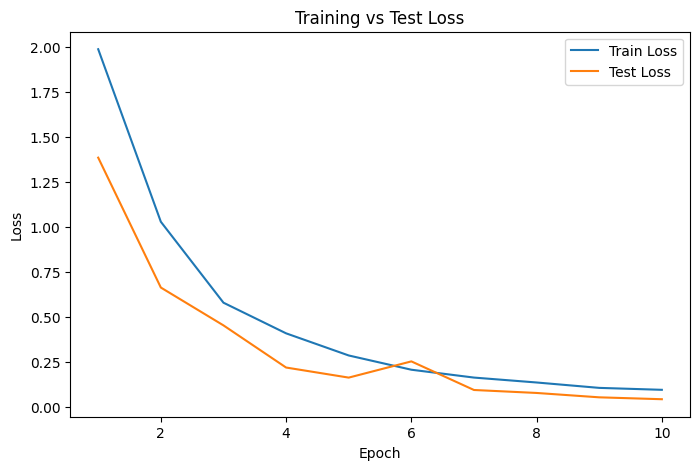

In [ ]:
#Train loss vs test_loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results.epoch, results.train_loss, label="Train Loss")
plt.plot(results.epoch, results.test_loss, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Test Loss")

plt.legend()

plt.show()

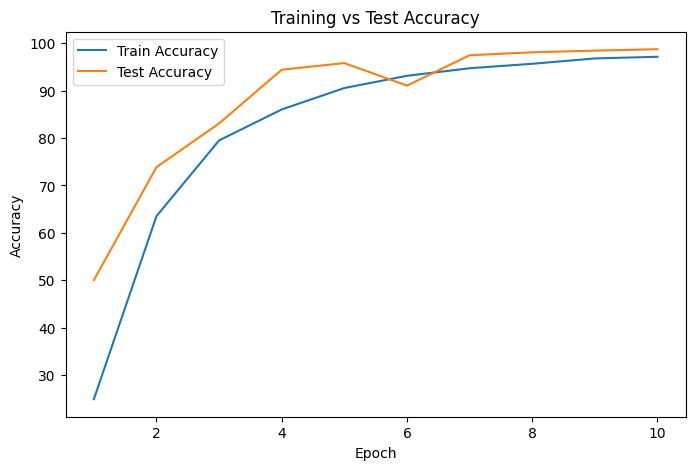

In [ ]:
#Train accuracy vs test_accuracy

plt.figure(figsize=(8,5))

plt.plot(results.epoch, results.train_accuracy, label="Train Accuracy")
plt.plot(results.epoch, results.test_accuracy, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Test Accuracy")
plt.legend()
plt.show()

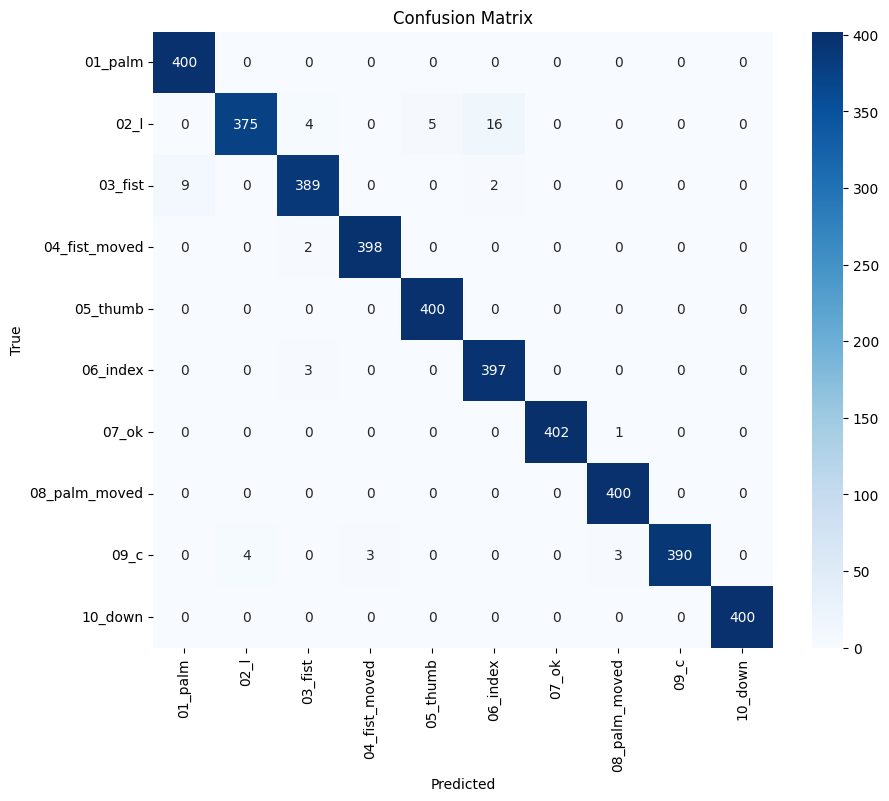

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = []
y_preds = []
class_names = dataset.classes

with torch.inference_mode():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = loaded_model_1(images)
    predicted = torch.argmax(outputs, 1)

    y_preds.extend(predicted.cpu().numpy())
    y_true.extend(labels.cpu().numpy())

cm = confusion_matrix(y_true, y_preds)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot = True,
            fmt="d",
            cmap="Blues",
            xticklabels = class_names,
            yticklabels=class_names
            )

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

## Observations
I believe the model did a pretty decent job because if you look at these images, some gestures are quite similar to each other

Gestures like;
* I and index
* Fist and thumb

You know what, lets visually represent some of the predictions

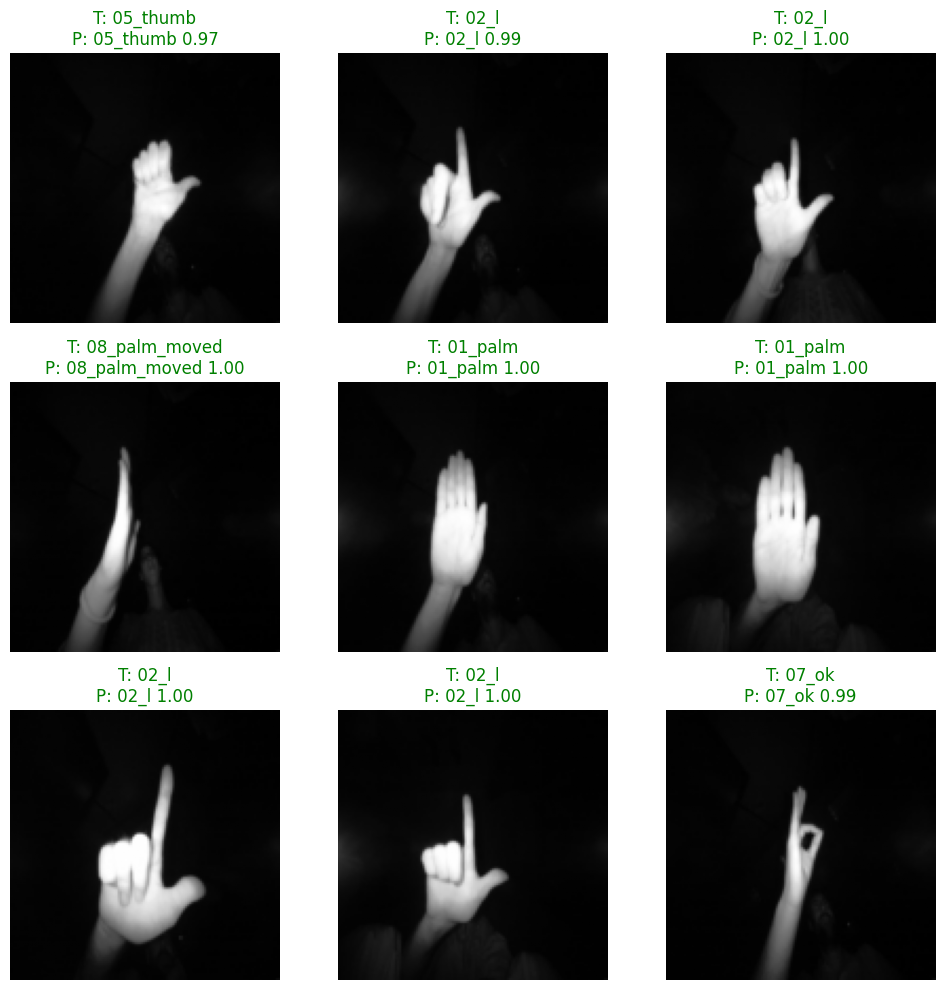

In [ ]:
# sample predictions
plt.figure(figsize=(10,10))
probs = torch.softmax(outputs, dim=1)


for i in range(9):
  img = images[i].squeeze(0)  #remove channel dimensions
  img = img * 0.5 + 0.5 #unnormalize

  true_label = class_names[labels[i]]
  pred_label = class_names[predicted[i]]
  conf = torch.max(probs[i]).item()

  color = "green" if true_label == pred_label else "red"

  plt.subplot(3, 3, i+1)
  plt.imshow(img, cmap="gray")

  plt.title(f"T: {true_label}\nP: {pred_label} {conf:.2f}", color=color)

  plt.axis("off")

plt.tight_layout()
plt.show()


Haha, our model is doing deliciously well man

Lets plot misclassified images

In [ ]:
loaded_model_1.eval()

misclassified_images = []
true_labels = []
pred_labels = []

class_names = dataset.classes

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = loaded_model_1(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):

            if preds[i] != labels[i]:

                misclassified_images.append(images[i].cpu())
                true_labels.append(labels[i].cpu())
                pred_labels.append(preds[i].cpu())

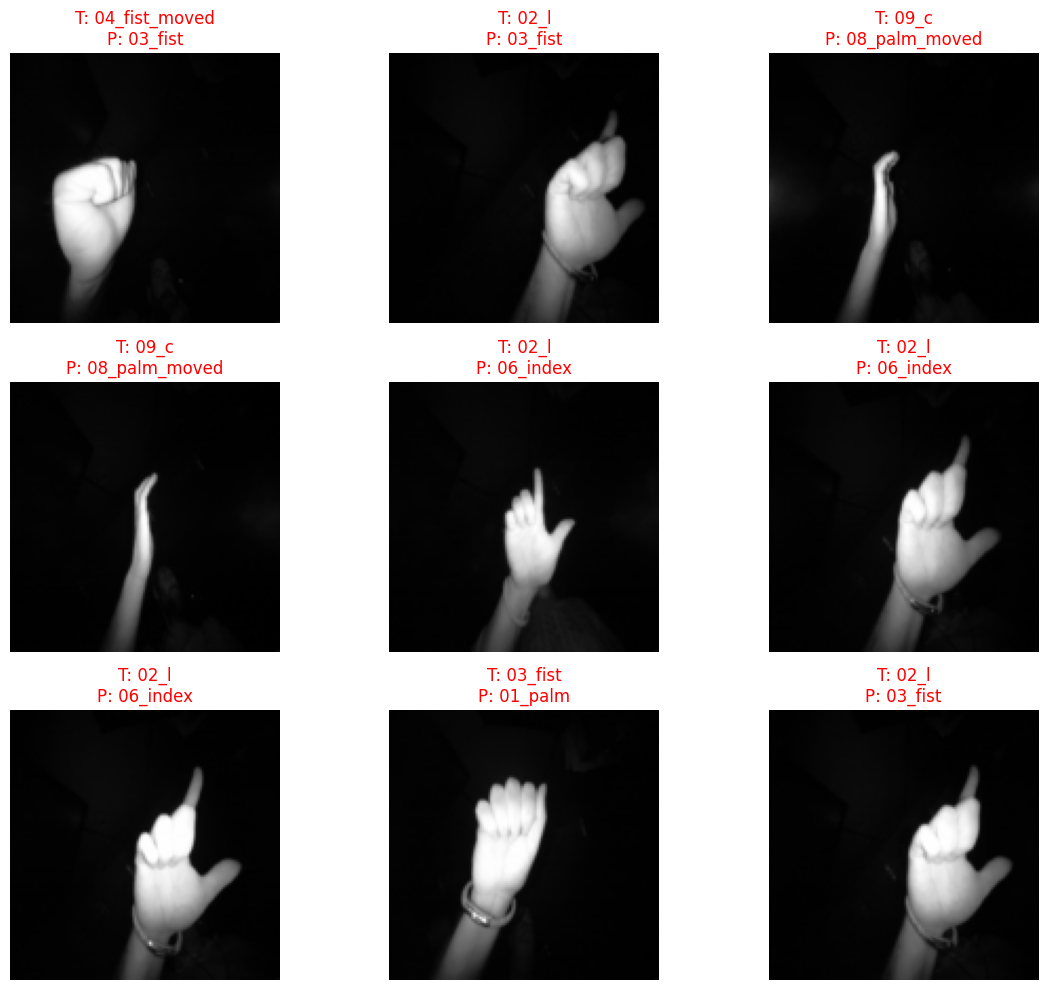

In [ ]:
plt.figure(figsize=(12,10))

num_images = min(9, len(misclassified_images))

for i in range(num_images):

    img = misclassified_images[i].squeeze(0)

    true_label = class_names[true_labels[i]]
    pred_label = class_names[pred_labels[i]]

    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap="gray")

    plt.title(f"T: {true_label}\nP: {pred_label}", color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()

## I have really spent a whole lot of time on this project and it was flipping amazing

## It was a good project because look as these misclassified images, looking all messed up. Ill say the model delivered well